In [168]:
# Data Handling
import pandas as pd
import numpy as np

# Text Preprocessing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Download NLTK data (run once)
nltk.download('stopwords')

# Visualization (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.metrics import roc_curve, auc

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# Models (3 required)
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import confusion_matrix, mean_squared_error, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import confusion_matrix

# Hyperparameter tuning (optional but good for marks)
from sklearn.model_selection import GridSearchCV

# Save Model
import pickle

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
fake_df=pd.read_csv('/content/Fake.csv', engine='python', on_bad_lines='skip')
true_df=pd.read_csv('/content/True.csv', engine='python', on_bad_lines='skip')

In [170]:
fake_df.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [171]:
true_df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [172]:
fake_df.info()

fake_df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15421 entries, 0 to 15420
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    15421 non-null  object
 1   text     15421 non-null  object
 2   subject  15421 non-null  object
 3   date     15421 non-null  object
dtypes: object(4)
memory usage: 482.0+ KB


,title,text,subject,date
count,15421,15421,15421,15421
unique,15414,15035,2,1558
top,MEDIA IGNORES Time That Bill Clinton FIRED His...,,News,"February 16, 2016"
freq,3,376,9050,32


In [173]:
true_df.info()
true_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10183 entries, 0 to 10182
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    10183 non-null  object
 1   text     10183 non-null  object
 2   subject  10183 non-null  object
 3   date     10183 non-null  object
dtypes: object(4)
memory usage: 318.3+ KB


,title,text,subject,date
count,10183,10183,10183,10183
unique,10074,10132,1,647
top,Factbox: Trump fills top jobs for his administ...,(Reuters) - Highlights for U.S. President Dona...,politicsNews,"November 9, 2016"
freq,14,8,10183,115


Add label Column

In [174]:
fake_df["label"] = 0
true_df["label"] = 1

In [175]:
data = pd.concat([fake_df, true_df], axis=0)

print(data.shape)

(25604, 5)


Shuffle the values

In [176]:
data = data.sample(frac=1).reset_index(drop=True)

In [177]:
data.head()

,title,text,subject,date,label
0,Donna Brazile CRUSHES Karl Rove For Making ‘J...,This is why Republicans lost the black vote an...,News,"June 6, 2016",0
1,U.S. civil rights groups to fan out on Nov. 8 ...,WASHINGTON (Reuters) - Donald Trump supporters...,politicsNews,"October 18, 2016",1
2,He ‘Belongs In An Institution’: James Comey’s...,Amateur president Donald Trump s repeated atta...,News,"May 20, 2017",0
3,Obama’s Doing Something BIG To Raise Pay For ...,"Throughout his presidency, President Obama has...",News,"May 18, 2016",0
4,FBI tells Congress it has not changed conclusi...,WASHINGTON (Reuters) - FBI Director James Come...,politicsNews,"November 6, 2016",1


Distribution of real and fake news

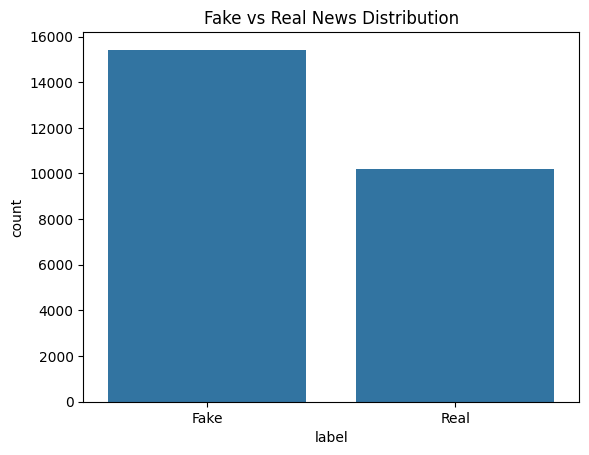

In [178]:
sns.countplot(x='label', data=data)
plt.title("Fake vs Real News Distribution")
plt.xticks([0,1], ['Fake','Real'])
plt.show()

Combining title and text as x

In [179]:
data["content"] = data["title"] + " " + data["text"]

X = data["content"]
y = data["label"]

wordcloud of fake news

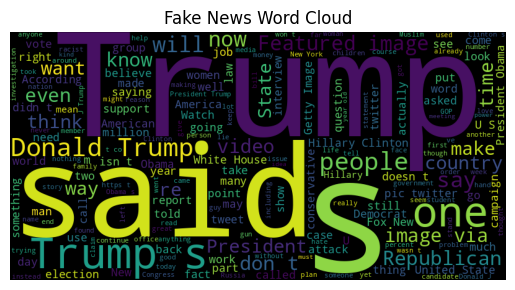

In [180]:
fake_words = ' '.join(data[data['label']==0]['content'])

wc = WordCloud(width=800, height=400).generate(fake_words)

plt.imshow(wc)
plt.axis('off')
plt.title("Fake News Word Cloud")
plt.show()

wordcloud of real news

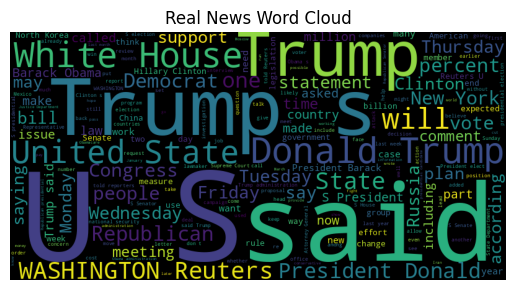

In [181]:
real_words = ' '.join(data[data['label']==1]['content'])

wc = WordCloud(width=800, height=400).generate(real_words)

plt.imshow(wc)
plt.axis('off')
plt.title("Real News Word Cloud")
plt.show()

length of sentences in fake and real news

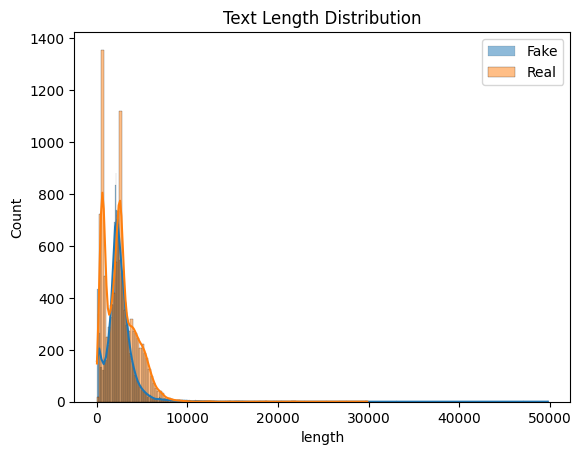

In [182]:
data['length'] = data['content'].apply(len)

sns.histplot(data[data['label']==0]['length'], label="Fake", kde=True)
sns.histplot(data[data['label']==1]['length'], label="Real", kde=True)

plt.legend()
plt.title("Text Length Distribution")
plt.show()

preprocessing

In [183]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W',' ',text)
    text = re.sub(r'\s+',' ',text)
    return text

data["content"] = data["content"].apply(clean_text)

data["content"].head()

,content
0,donna brazile crushes karl rove for making jo...
1,u s civil rights groups to fan out on nov 8 to...
2,he belongs in an institution james comey s re...
3,obama s doing something big to raise pay for ...
4,fbi tells congress it has not changed conclusi...


Drop unnessesary columns

In [184]:
data = data.drop(["title","text","subject","date"], axis=1)

convert everyting to lowercase

In [185]:
data["content"] = data["content"].str.lower()

Train test Split

In [186]:
X_train, X_test, y_train, y_test = train_test_split(
    data["content"], y, test_size=0.2, random_state=42
)

In [187]:
vectorizer = TfidfVectorizer(stop_words="english", max_df=0.7)

X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

Logistic regression

In [188]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

Naive Bayes

In [189]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train, y_train)

MultinomialNB()

KNN

In [190]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

SVM

In [191]:
from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train, y_train)

LinearSVC()

Evaluate models

In [192]:

def evaluate_model(name, y_test, pred):
    print(f"\n{name} Performance:")
    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))
    print("MAE      :", mean_absolute_error(y_test, pred))
    print("MSE      :", mean_squared_error(y_test, pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))


# Predictions
pred1 = lr.predict(X_test)
pred2 = nb.predict(X_test)
pred3 = knn.predict(X_test)
pred4 = svm.predict(X_test)

# Evaluation
evaluate_model("Logistic Regression", y_test, pred1)
evaluate_model("Naive Bayes", y_test, pred2)
evaluate_model("KNN", y_test, pred3)
evaluate_model("SVM", y_test, pred4)


Logistic Regression Performance:
Accuracy : 0.9800820152314001
Precision: 0.9779411764705882
Recall   : 0.9722222222222222
F1 Score : 0.9750733137829912
MAE      : 0.01991798476859988
MSE      : 0.01991798476859988
Confusion Matrix:
 [[3024   45]
 [  57 1995]]

Naive Bayes Performance:
Accuracy : 0.9240382737746534
Precision: 0.9351125065410779
Recall   : 0.8708576998050682
F1 Score : 0.9018420388594499
MAE      : 0.07596172622534661
MSE      : 0.07596172622534661
Confusion Matrix:
 [[2945  124]
 [ 265 1787]]

KNN Performance:
Accuracy : 0.8293302089435657
Precision: 0.7309803921568627
Recall   : 0.9083820662768031
F1 Score : 0.8100825727944372
MAE      : 0.1706697910564343
MSE      : 0.1706697910564343
Confusion Matrix:
 [[2383  686]
 [ 188 1864]]

SVM Performance:
Accuracy : 0.9908221050576059
Precision: 0.9868868382710053
Recall   : 0.9902534113060428
F1 Score : 0.9885672585745561
MAE      : 0.009177894942394065
MSE      : 0.009177894942394065
Confusion Matrix:
 [[3042   27]
 [  20

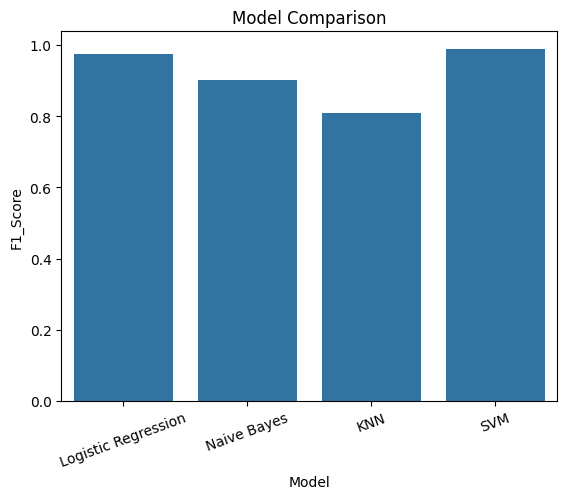

In [193]:
results = pd.DataFrame({
    'Model': ['Logistic Regression','Naive Bayes','KNN','SVM'],
    'F1_Score': [
        f1_score(y_test, pred1),
        f1_score(y_test, pred2),
        f1_score(y_test, pred3),
        f1_score(y_test, pred4)
    ]
})

sns.barplot(x='Model', y='F1_Score', data=results)
plt.title("Model Comparison")
plt.xticks(rotation=20)
plt.show()

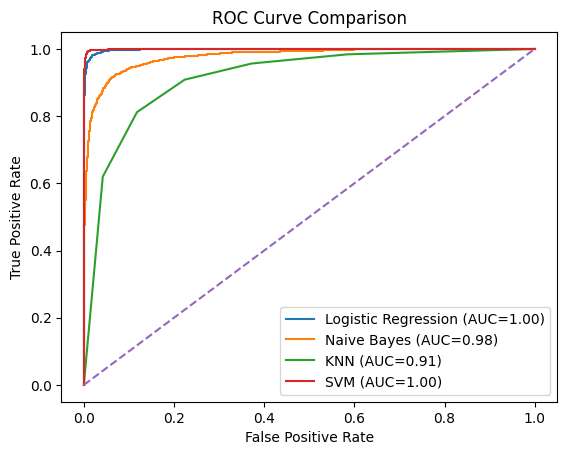

In [194]:


# Probabilities / scores
lr_probs = lr.predict_proba(X_test)[:,1]
nb_probs = nb.predict_proba(X_test)[:,1]
knn_probs = knn.predict_proba(X_test)[:,1]
svm_scores = svm.decision_function(X_test)

# ROC values
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probs)
knn_fpr, knn_tpr, _ = roc_curve(y_test, knn_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_scores)

# AUC scores
lr_auc = auc(lr_fpr, lr_tpr)
nb_auc = auc(nb_fpr, nb_tpr)
knn_auc = auc(knn_fpr, knn_tpr)
svm_auc = auc(svm_fpr, svm_tpr)

# Plot
plt.figure()

plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC={lr_auc:.2f})')
plt.plot(nb_fpr, nb_tpr, label=f'Naive Bayes (AUC={nb_auc:.2f})')
plt.plot(knn_fpr, knn_tpr, label=f'KNN (AUC={knn_auc:.2f})')
plt.plot(svm_fpr, svm_tpr, label=f'SVM (AUC={svm_auc:.2f})')

plt.plot([0,1], [0,1], linestyle='--')  # random line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

SVM model is giving best accuracy, precision, recall, f1 score

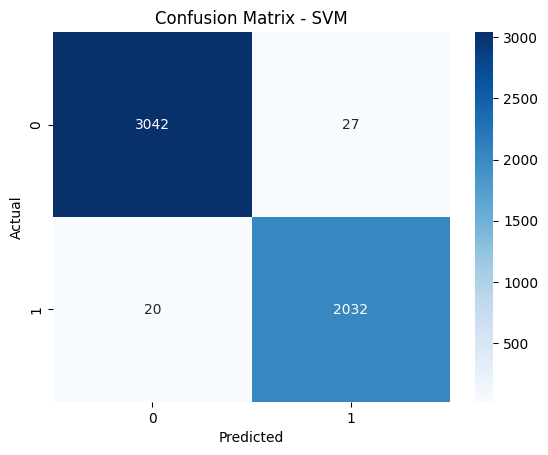

In [195]:

cm = confusion_matrix(y_test, pred4)  # SVM

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Save the model

In [196]:
pickle.dump(svm, open("model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))

In [197]:
from google.colab import files

files.download("model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>